# Задание 1

Retention – один из самых важных показателей в компании. Ваша задача – написать функцию, которая будет считать retention игроков (по дням от даты регистрации игрока). Данные лежат в папке shared и имеют следующую структуру:

    shared/problem1-reg_data.csv – данные о времени регистрации
    shared/problem1-auth_data.csv – данные о времени захода пользователей в игру
Функция должна быть написана на python. В ходе решения можно тестировать работу функции как на полном датасете, так и на части (сэмпле) данных.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.stats import ttest_ind, norm

# Загрузка с правильным разделителем
reg_df = pd.read_csv('shared/problem1-reg_data.csv', sep=';')
auth_df = pd.read_csv('shared/problem1-auth_data.csv', sep=';')
reg_df

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5
...,...,...
999995,1600874034,1110618
999996,1600874086,1110619
999997,1600874139,1110620
999998,1600874191,1110621


In [3]:
auth_df

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2
...,...,...
9601008,1600874034,1110618
9601009,1600874086,1110619
9601010,1600874139,1110620
9601011,1600874191,1110621


In [4]:
# Преобразуем дату

def ts_to_date(ts):
    return datetime.utcfromtimestamp(ts).date()

reg_df['reg_date'] = reg_df['reg_ts'].apply(ts_to_date)
auth_df['auth_date'] = auth_df['auth_ts'].apply(ts_to_date)

reg_df

,reg_ts,uid,reg_date
0,911382223,1,1998-11-18
1,932683089,2,1999-07-22
2,947802447,3,2000-01-13
3,959523541,4,2000-05-28
4,969103313,5,2000-09-16
...,...,...,...
999995,1600874034,1110618,2020-09-23
999996,1600874086,1110619,2020-09-23
999997,1600874139,1110620,2020-09-23
999998,1600874191,1110621,2020-09-23


In [5]:
auth_df

,auth_ts,uid,auth_date
0,911382223,1,1998-11-18
1,932683089,2,1999-07-22
2,932921206,2,1999-07-25
3,933393015,2,1999-07-31
4,933875379,2,1999-08-05
...,...,...,...
9601008,1600874034,1110618,2020-09-23
9601009,1600874086,1110619,2020-09-23
9601010,1600874139,1110620,2020-09-23
9601011,1600874191,1110621,2020-09-23


Retention N-го дня — это доля пользователей, которые вернулись в приложение в N-й день после регистрации (день регистрации считается днём 0).По условию задания нужна функция, которая считает retention «по дням от даты регистрации». Функция возвращает словарь, где ключ — N, значение — доля вернувшихся в день N. Пользователь считается «вернувшимся» в день N, если у него есть хотя бы одна авторизация в день reg_date + N. Retention(1) = количество пользователей, у которых есть сессия в день reg_date + 1. 

Функция будет принимать DataFrame регистраций, DataFrame авторизаций и список дней, а возвращать словарь retention.

In [63]:
def calculate_retention(reg_data, auth_data, days_list):
    # Объединяем регистрации и авторизации
    merged = reg_data[['uid', 'reg_date']].merge(
        auth_data[['uid', 'auth_date']], on='uid', how='left'
    )
    merged['day_diff'] = (merged['auth_date'] - merged['reg_date']).dt.days
    
    total_users = reg_data['uid'].nunique()
    retention = {}
    for day in days_list:
        returned = merged[merged['day_diff'] == day]['uid'].nunique()
        retention[day] = round(returned / total_users, 4) if total_users > 0 else 0
    return retention

In [64]:
# Создание сэмпла чтобы расчеты были легче
sample_uids = reg_df['uid'].unique()[:1000]   # первые 1000 пользователей
reg_sample = reg_df[reg_df['uid'].isin(sample_uids)]
auth_sample = auth_df[auth_df['uid'].isin(sample_uids)]

In [65]:
#тест
result = calculate_retention(reg_sample, auth_sample, [1, 3, 7, 30])
result

{1: 0.02, 3: 0.053, 7: 0.065, 30: 0.032}

# Задание 2

Имеются результаты A/B теста, в котором двум группам пользователей предлагались различные наборы акционных предложений. Известно, что ARPU в тестовой группе выше на 5%, чем в контрольной. При этом в контрольной группе 1928 игроков из 202103 оказались платящими, а в тестовой – 1805 из 202667.

Какой набор предложений можно считать лучшим? Какие метрики стоит проанализировать для принятия правильного решения и как?

Формат данных:
user_id	revenue	testgroup
1	0	b
2	0	a
3	0	a
4	0	b
5	0	b

In [9]:
df = pd.read_csv('Проект_1_Задание_2.csv', sep=';')
df

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b
...,...,...,...
404765,404766,0,a
404766,404767,0,b
404767,404768,231,a
404768,404769,0,a


In [10]:
# Предварительный анализ
# Платящие
df['is_payer'] = (df['revenue'] > 0).astype(int)

# Группировка
group_stats = df.groupby('testgroup').agg(
    total_users = ('user_id', 'count'),
    payers = ('is_payer', 'sum'),
    total_revenue = ('revenue', 'sum')
).reset_index()

group_stats['conversion'] = group_stats['payers'] / group_stats['total_users']
group_stats['ARPU'] = group_stats['total_revenue'] / group_stats['total_users']
group_stats['ARPPU'] = group_stats['total_revenue'] / group_stats['payers']

group_stats

,testgroup,total_users,payers,total_revenue,conversion,ARPU,ARPPU
0,a,202103,1928,5136189,0.009540,25.413720,2663.998444
1,b,202667,1805,5421603,0.008906,26.751287,3003.658172


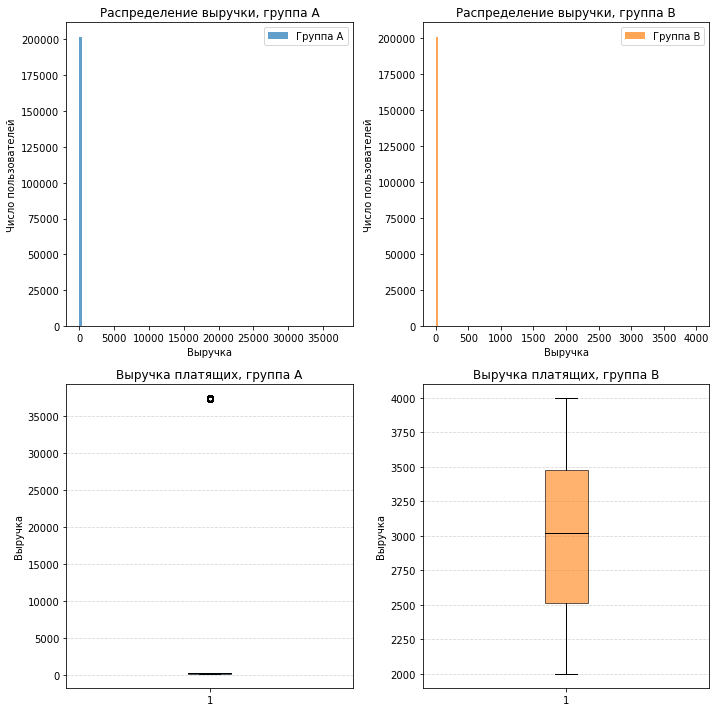

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# --- Верхний ряд: гистограммы выручки ---
for i, group in enumerate(['a', 'b']):
    subset = df[df['testgroup'] == group]['revenue']
    color = '#1f77b4' if group == 'a' else '#ff7f0e'
    axes[0, i].hist(subset, bins=100, color=color, alpha=0.7, label=f'Группа {group.upper()}')
    axes[0, i].set_title(f'Распределение выручки, группа {group.upper()}')
    axes[0, i].set_xlabel('Выручка')
    axes[0, i].set_ylabel('Число пользователей')
    axes[0, i].legend()

# --- Нижний ряд: ящики с усами для платящих ---
for i, group in enumerate(['a', 'b']):
    payers_rev = df[(df['testgroup'] == group) & (df['revenue'] > 0)]['revenue']
    color = '#1f77b4' if group == 'a' else '#ff7f0e'
    bp = axes[1, i].boxplot(payers_rev, vert=True, patch_artist=True,
                            boxprops=dict(facecolor=color, alpha=0.6),
                            medianprops=dict(color='black'))
    axes[1, i].set_title(f'Выручка платящих, группа {group.upper()}')
    axes[1, i].set_ylabel('Выручка')
    axes[1, i].grid(axis='y', linestyle='--', alpha=0.5)

# Убираем пустые третьи панели
axes[0, 2].set_visible(False)
axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()


Распределение выручки около нуля, т.е. платящих пользоватлей крайне мало. 
Ящик с усами для платящих демонстрирует огромные выбросы у группы А, боксплот не видно из-за масштаба выбросов. 

   

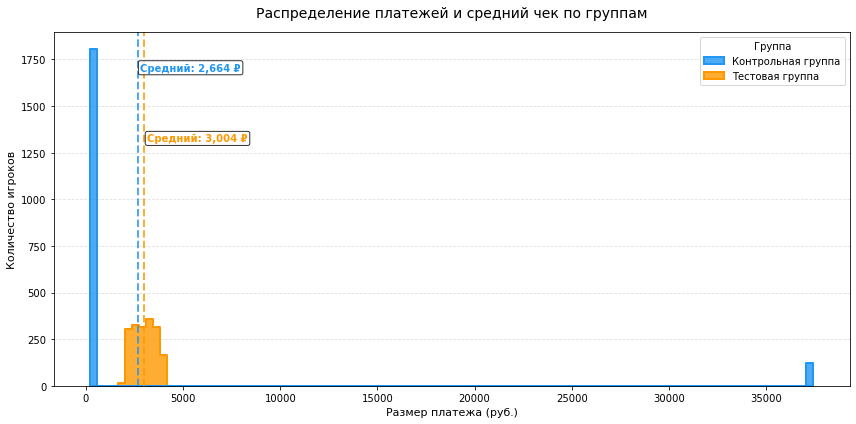

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Платящие
payers = df[df['revenue'] > 0].copy()
payers['Группа'] = payers['testgroup'].map({'a': 'Контрольная группа', 'b': 'Тестовая группа'})

means = payers.groupby('Группа')['revenue'].mean()
colors = ['#2196F3', '#FF9800']

plt.figure(figsize=(12, 6))

sns.histplot(
    data=payers,
    x='revenue',
    hue='Группа',
    element='step',
    palette=colors,
    linewidth=2,
    alpha=0.8
)

ax = plt.gca()
ymax = ax.get_ylim()[1]  # максимальная высота гистограммы

# Разные высоты для плашек, чтобы не пересекались
heights = [0.9 * ymax, 0.7 * ymax]  # первая выше, вторая ниже

for i, (group, mean_val) in enumerate(means.items()):
    plt.axvline(mean_val, color=colors[i], linestyle='--', linewidth=2, alpha=0.8)
    plt.text(mean_val * 1.05, heights[i], f'Средний: {mean_val:,.0f} ₽',
             color=colors[i], fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8),
             ha='left', va='center')

ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.get_major_formatter().set_scientific(False)

plt.title('Распределение платежей и средний чек по группам', fontsize=14, pad=15)
plt.xlabel('Размер платежа (руб.)', fontsize=11)
plt.ylabel('Количество игроков', fontsize=11)

ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

В контрольной группе (А) виден отчётливый пик в районе 300–400 рублей — большое число игроков совершают небольшие покупки. В тестовой группе (B) этот пик выражен слабее около 3 000 рублей — там сконцентрирована основная масса платящих. В контрольной группе наблюдается небольшой, но заметный пик экстремально крупных платежей (около 37 000 рублей). В тестовой группе подобных «китов» нет. Несмотря на  разницу в форме распределений, средние очень близки друг к другу. График наглядно демонстрирует, что структура платящей аудитории в группах принципиально разная:

    Группа А: много мелких плательщиков + единичные сверхкрупные.

    Группа B: устойчивое ядро крупных плательщиков без выбросов.
    
Тестовый набор акций меняет структуру монетизации — вместо большого числа мелких платежей мы получаем устойчивый поток средних.

 Для принятия правильного решения стоит проанализировать:
 1. Конверсия в платящего - доля пользователей, которые совершили хотя бы одну покупку. Повышение конверсии означает, что акция мотивирует игроков совершать покупки. Снижение конверсии может сигнализировать, что тестовый набор отпугивает игроков.
 2. ARPU (средняя выручка на пользователя, в т.ч. пользователи без покупок). Если ARPU тестовой группы статистически значимо выше, значит, в среднем каждый пользователь приносит больше денег благодаря тестовым наборам. ARPU может расти и за счет повышения доли платящих и за счет повышения среднего чека. 
 3. ARPPU (средняя выручка на платящего пользователя, пользователи без покупок не учитываются). Стат. значимый рост ARPPU  говорит о том, что тестовый набор стимулирует более дорогие покупки. 

Эти три показателя связаны: ARPU = Конверсия × ARPPU

In [12]:
# Разбиваем на контрольную (a) и тестовую (b) группы

control = df[df['testgroup'] == 'a']
test = df[df['testgroup'] == 'b']

N_control = len(control)
N_test = len(test)
N_control


202103

In [13]:
N_test

202667

In [14]:
# Конверсия
payers_control = (control['revenue'] > 0).sum()
payers_test = (test['revenue'] > 0).sum()

conv_control = payers_control / N_control
conv_test = payers_test / N_test
conv_control

0.009539690157988749

In [15]:
conv_test

0.008906235351586593

In [16]:
payers_control

1928

In [17]:
payers_test

1805

In [18]:
# ARPU (средняя выручка на пользователя)
arpu_control = control['revenue'].mean()
arpu_test = test['revenue'].mean()
arpu_control

25.413719736965806

In [19]:
arpu_test

26.75128659327863

In [20]:
# ARPPU (средняя выручка на платящего)
arppu_control = control[control['revenue'] > 0]['revenue'].mean()
arppu_test = test[test['revenue'] > 0]['revenue'].mean()
arppu_control

2663.9984439834025

In [21]:
arppu_test

3003.6581717451522

In [22]:

print(f"\nКонверсия контроль: {conv_control:.2%}")
print(f"Конверсия тест:    {conv_test:.2%}")
print(f"ARPU контроль:     {arpu_control:.2f}")
print(f"ARPU тест:         {arpu_test:.2f}")
print(f"ARPPU контроль:    {arppu_control:.2f}")
print(f"ARPPU тест:        {arppu_test:.2f}")



Конверсия контроль: 0.95%
Конверсия тест:    0.89%
ARPU контроль:     25.41
ARPU тест:         26.75
ARPPU контроль:    2664.00
ARPPU тест:        3003.66


Тестовое предложение принесло больше денег в расчёте на каждого пользователя (ARPU вырос на 5.3%), но при этом сократило долю платящих (конверсия ниже на 6%). Платящих пользователей стало меньше, но они стали платить больше – ARPPU больше почти на 13%.
Прежду чем делать вывод о том, какой набор предложений можно считать лучшим, нужно провести тест стат. значимости. Для всех статистических тестов в рамках данного исследования установим стандартный уровень значимости α=0,05.

Для конверсии: данные бинарные, t-тест некорректен -он для непрерывных величин. 
Для сравнения конверсии (качественным бинарным признаком: «купил / не купил») при большом объеме выборки (около 202 тысяч наблюдений в каждой группе) лучше всего подходит Z-тест.
Условия Z-теста:
 1. Сравнение долей (пропорций) 
 2. Сравнение средних величин 
 3. Независимость наблюдений

Нулевая гипотеза (H₀): Конверсия в платящего пользователя в контрольной группе равна конверсии в тестовой группе.

Альтернативная гипотеза (H₁): Конверсии в двух группах различаются.

In [23]:
from statsmodels.stats.proportion import proportions_ztest


# 4. Формируем списки для функции
successes = [payers_control, payers_test]
nobs      = [N_control, N_test]

# 5. Вызываем Z-тест для разницы пропорций
z_stat, p_value = proportions_ztest(count=successes, nobs=nobs)
p_value

0.035028524642854865

Также в данном случае уместен критерий хи-квадрат 

In [70]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# Фактические наблюдения
observed = np.array([[1928, 202103 - 1928],   # A: платящие, не платящие
                     [1805, 202667 - 1805]])  # B: платящие, не платящие

chi2, p, dof, expected = chi2_contingency(observed, correction=False)

p


0.0350285246428554

Разница в конверсиях статистически значима (p < 0.05)

Распределение ARPU вряд ли будет нормальным: обычно большинство пользователей не платит, небольшое количество пользователей платит.  Считается, что в случае нормального распределения ЦПТ начинает действовать быстрее (т.е. требует меньшего размера выборки, чтобы получилась эта закономерность), но с ненормальными в конечном итоге это также сработает.Выборка большая, поэтому t-тест может дать приемлемый p-value для средней разницы.
условия t-критерия Стьюдента:
 1. Независимость наблюдений
 2. Отсутствие аномальных наблюдений (выбросов)
 3. Равенство дисперсий между ГС
 4. Нормальность обеих ГС
 
Проверим нормальность распределения выборок

In [25]:
# Извлечение выручки всех пользователей (для ARPU)
revenue_control_all = control['revenue']
revenue_test_all = test['revenue']

# Извлечение выручки только платящих (для ARPPU)
revenue_control_payers = control[control['revenue'] > 0]['revenue']
revenue_test_payers = test[test['revenue'] > 0]['revenue']

<Figure size 432x288 with 0 Axes>

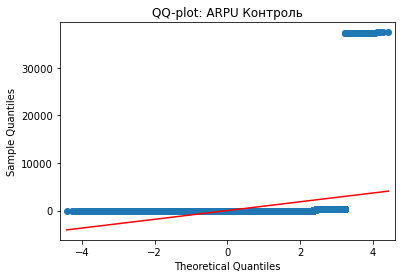

<Figure size 432x288 with 0 Axes>

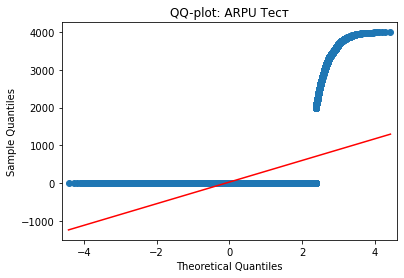

In [26]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# QQ-plot для контрольной группы (все пользователи)
plt.figure()
sm.qqplot(revenue_control_all, line='s')
plt.title('QQ-plot: ARPU Контроль')
plt.show()

# QQ-plot для тестовой группы (все пользователи)
plt.figure()
sm.qqplot(revenue_test_all, line='s')
plt.title('QQ-plot: ARPU Тест')
plt.show()

Из графиков видно, что распределение не нормально

<Figure size 432x288 with 0 Axes>

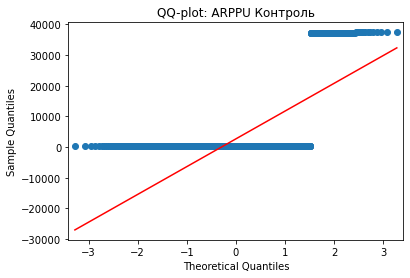

<Figure size 432x288 with 0 Axes>

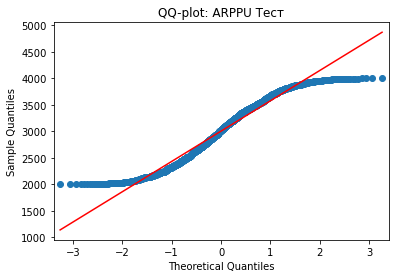

In [27]:
# QQ-plot для контрольной группы (платящие)
plt.figure()
sm.qqplot(revenue_control_payers, line='s')
plt.title('QQ-plot: ARPPU Контроль')
plt.show()

# QQ-plot для тестовой группы (платящие)
plt.figure()
sm.qqplot(revenue_test_payers, line='s')
plt.title('QQ-plot: ARPPU Тест')
plt.show()

График для контрольной группы показывает не нормальное распределение, график для тестовой группы показывает отклонения от прямой

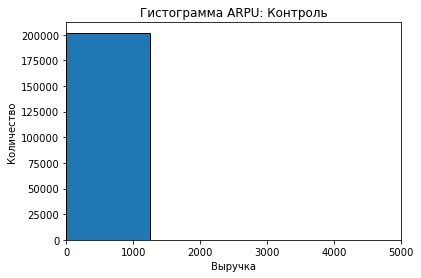

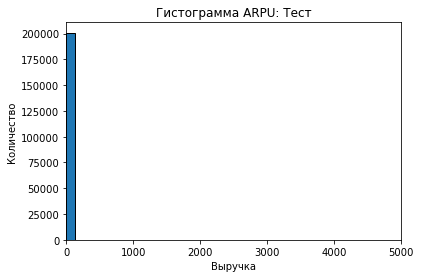

In [28]:
# Гистограмма для контрольной группы (все пользователи)
plt.figure()
plt.hist(revenue_control_all, bins=30, edgecolor='black')
plt.title('Гистограмма ARPU: Контроль')
plt.xlabel('Выручка')
plt.ylabel('Количество')
plt.xlim(0, 5000)  # уберите или измените при необходимости
plt.show()

# Гистограмма для тестовой группы (все пользователи)
plt.figure()
plt.hist(revenue_test_all, bins=30, edgecolor='black')
plt.title('Гистограмма ARPU: Тест')
plt.xlabel('Выручка')
plt.ylabel('Количество')
plt.xlim(0, 5000)
plt.show()

Распределение не нормально

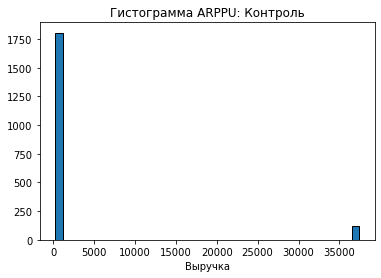

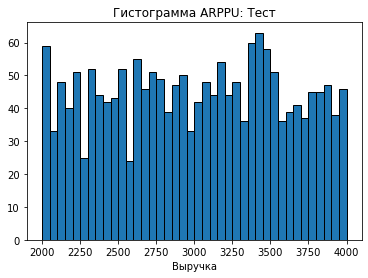

In [29]:
# Гистограмма для контрольной группы (платящие)
plt.figure()
plt.hist(revenue_control_payers, bins=40, edgecolor='black')
plt.title('Гистограмма ARPPU: Контроль')
plt.xlabel('Выручка')
plt.show()

# Гистограмма для тестовой группы (платящие)
plt.figure()
plt.hist(revenue_test_payers, bins=40, edgecolor='black')
plt.title('Гистограмма ARPPU: Тест')
plt.xlabel('Выручка')
plt.show()

Распределение контрольной группы не нормально, тестовой отдаленно похоже на нормальное, но нормальным не является. 

T-тест устойчив к нарушениям нормальности при больших выборках
При столь больших выборках тест Левена почти всегда будет отвергать нулевую гипотезу о равенстве дисперсий из-за гигантской мощности, поэтому используем correction=True, чтобы всегда использовать вариант Уэлча.

T-тест для ARPU (средняя выручка на пользователя)

    Нулевая гипотеза (H₀):
    Средний ARPU в контрольной группе равен среднему ARPU в тестовой группе.

    Альтернативная гипотеза (H₁):
    Средние ARPU в двух группах различаются.

In [32]:
import pingouin as pg

ttest_arpu = pg.ttest(revenue_test_all, revenue_control_all, correction=True)
ttest_arpu



,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.623488,240991.130782,two-sided,0.532965,"[-2.87, 5.54]",0.001962,0.004,0.095694


Разница в ARPU НЕ значима p >= 0.05

T-тест для ARPPU (средняя выручка на платящего)

    Нулевая гипотеза (H₀):
    Средний ARPPU в контрольной группе равен среднему ARPPU в тестовой группе.

    Альтернативная гипотеза (H₁):
    Средние ARPPU в двух группах различаются.


In [33]:
ttest_arppu = pg.ttest(revenue_test_payers, revenue_control_payers, correction=True)
ttest_arppu

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.64463,1943.481522,two-sided,0.100208,"[-65.38, 744.7]",0.052132,0.142,0.356381


Разница в ARPPU НЕ значима p >= 0.05

t-тест подходит не идеально в данном случае для ARPU И ARPPU, ранее было указано, что данные распределены не нормально.
В таком случае на помощь может придти Тест Манна-Уитни (U-тест) или перестановочный тест. 
Критерий Манна-Уитни  не проверяет разницу средних и «срезает» влияние крупных плательщиков, которые генерируют основную прибыль компании. В таких сценариях перестановочный тест с проверкой разницы средних значений кажется более предпочтительным.


Нулевая гипотеза (H₀) - метрика в контрольной группе равна метрике в тестовой группе.

Альтернативная гипотеза (H₁) - Метрики не равны, разница не может быть объяснена только случайностью.
    
    

=== ARPU ===
Среднее A: 25.4137, Среднее B: 26.7513
Наблюдаемая разница (B - A): 1.3376
P-value (перестановочный тест): 0.5362
Значимость на уровне 0.05: Нет

=== ARPPU ===
Среднее A: 2663.9984, Среднее B: 3003.6582
Наблюдаемая разница (B - A): 339.6597
P-value (перестановочный тест): 0.1107
Значимость на уровне 0.05: Нет


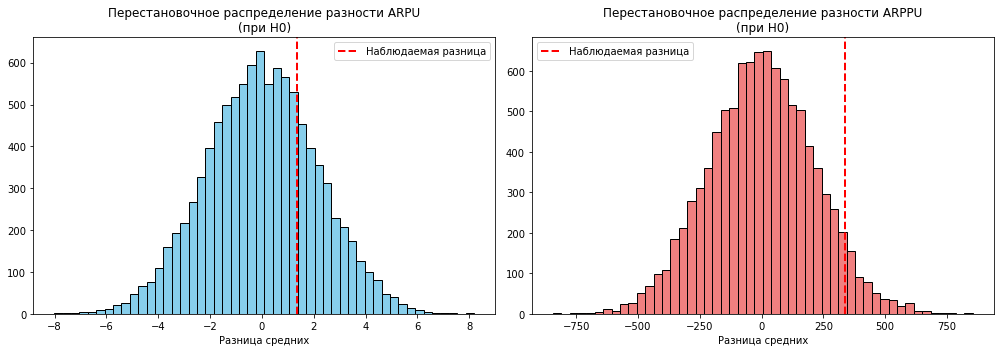

In [52]:
import numpy as np
import matplotlib.pyplot as plt

def permutation_test(x, y, statistic=np.mean, n_perm=10000, random_state=42):
    """
    Перестановочный тест для разности statistic(y) - statistic(x).
    Возвращает наблюдаемую разницу, p-value (двусторонний) и массив разниц при H0.
    """
    rng = np.random.default_rng(random_state)
    observed_diff = statistic(y) - statistic(x)
    combined = np.concatenate([x, y])
    n_x = len(x)
    perm_diffs = np.empty(n_perm)
    
    for i in range(n_perm):
        rng.shuffle(combined)
        perm_diffs[i] = statistic(combined[n_x:]) - statistic(combined[:n_x])
    
    # Двусторонний p-value
    p = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
    return observed_diff, p, perm_diffs

# Данные: полная выборка (все пользователи фрагмента)
rev_a = df[df['testgroup'] == 'a']['revenue'].values
rev_b = df[df['testgroup'] == 'b']['revenue'].values

# ARPU: средняя выручка на всех пользователей
diff_arpu, p_arpu, perm_arpu = permutation_test(rev_a, rev_b)

print(f"=== ARPU ===")
print(f"Среднее A: {np.mean(rev_a):.4f}, Среднее B: {np.mean(rev_b):.4f}")
print(f"Наблюдаемая разница (B - A): {diff_arpu:.4f}")
print(f"P-value (перестановочный тест): {p_arpu:.4f}")
print("Значимость на уровне 0.05:", "Да" if p_arpu < 0.05 else "Нет")

# ARPPU: только платящие
payers_a = df[(df['testgroup'] == 'a') & (df['revenue'] > 0)]['revenue'].values
payers_b = df[(df['testgroup'] == 'b') & (df['revenue'] > 0)]['revenue'].values

diff_arppu, p_arppu, perm_arppu = permutation_test(payers_a, payers_b)

print(f"\n=== ARPPU ===")
print(f"Среднее A: {np.mean(payers_a):.4f}, Среднее B: {np.mean(payers_b):.4f}")
print(f"Наблюдаемая разница (B - A): {diff_arppu:.4f}")
print(f"P-value (перестановочный тест): {p_arppu:.4f}")
print("Значимость на уровне 0.05:", "Да" if p_arppu < 0.05 else "Нет")

# Визуализация распределений разниц при H0
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(perm_arpu, bins=50, color='skyblue', edgecolor='black')
axes[0].axvline(diff_arpu, color='red', linestyle='--', linewidth=2, label='Наблюдаемая разница')
axes[0].set_title('Перестановочное распределение разности ARPU\n(при H0)')
axes[0].set_xlabel('Разница средних')
axes[0].legend()

axes[1].hist(perm_arppu, bins=50, color='lightcoral', edgecolor='black')
axes[1].axvline(diff_arppu, color='red', linestyle='--', linewidth=2, label='Наблюдаемая разница')
axes[1].set_title('Перестановочное распределение разности ARPPU\n(при H0)')
axes[1].set_xlabel('Разница средних')
axes[1].legend()

plt.tight_layout()
plt.show()

Гистограмма сосредоточена вокруг нуля: при отсутствии реального эффекта случайные колебания будут примерно симметричны относительно нуля. Красная пунктирная вертикальная линия отмечает наблюдаемую в реальном эксперименте разницу, которую мы посчитали на исходных данных. Положение этой линии относительно гистограммы говорит о том, насколько наша разница необычна:

Если линия находится далеко в хвосте распределения, значит вероятность получить такое или более экстремальное различие очень мала, мы отвергаем H0.

Если линия близка к центру, то наблюдаемая разница вполне типична для случайных колебаний, H0 не отвергается.

Перестановочный тест дал p-value выше порога. t-тест Уэлча дал аналогичный результат. Это означает, что наблюдаемая разница обусловлена случайностью.

Таким образом, конверсия статистически значимо снизилась в тестовой группе.

Различие ARPU не является статистически значимым.

Различие ARPPU не является статистически значимым.


На основе проведённого анализа лучшим следует считать контрольный набор предложений (a):
Если тестовая группа получила более дорогие предложения, это может объяснить рост ARPPU, но снижение конверсии говорит, что пользователи стали реже совершать покупки.
Тестовый набор не привёл к статистически значимому увеличению ARPU или ARPPU. Тестовый набор статистически значимо снизил конверсию. 
Следовательно, тестовый набор не доказал своей эффективности. 


# Задание 3

В игре Plants & Gardens каждый месяц проводятся тематические события, ограниченные по времени. В них игроки могут получить уникальные предметы для сада и персонажей, дополнительные монеты или бонусы. Для получения награды требуется пройти ряд уровней за определенное время. С помощью каких метрик можно оценить результаты последнего прошедшего события?

Предположим, в другом событии мы усложнили механику событий так, что при каждой неудачной попытке выполнения уровня игрок будет откатываться на несколько уровней назад. Изменится ли набор метрик оценки результата? Если да, то как?

Результаты последнего прошедшего события можно оценить с помощью метрик:

    1. Доля активных пользователей, начавших событие (запустили первый уровень), насколько событие интересно игрокам? 
    2. Среднее количество пройденных уровней, игроки вовлечены в событие? 
    3. Доля игроков полностью завершивших событие, насколько игроки мотивированы дойти до конца? 
    4. Конверсия между этапами: старт - середина - финиш, насколько событие интересно игрокам? 
    5. Среднее время, потраченное на прохождение всего события, долго ли проходить событие?
    6. ARPU / ARPPU участников + сравнение с прошлыми периодами, событие влияет на прибыль?
    7. Процент участников, совершивших хотя бы одну покупку в рамках события, событие мотивирует на покупку? 
    8. Доля игроков, совершивших свою самую первую покупку именно во время нового события, событие стимулирует новых игроков к покупкам? 
    9. Retention, повляело ли событие на удержание? 
    10. Доля игроков, переставших заходить в игру до окончания события, раздрпажает ли игроков событие? 
    11. Определение уровня, на котором игроки массово забросили событие, какой уровень самый сложный? Оправдана ли его сложность? 
    12. Количество использованных бонусов для прохождения события, нужно ли стимулирвоать игркоов к покупке платных бонусов? 
    13. Среднее время, проведенное в игре, вовлекает ли игроков событие?
    14. Количество входа в игру в период времени, повышает ли интерес игроков событие? 
    15. Стоимость потраченных бонусов, событие приносит больше прибыли чем стандартный режим? 
    16. Общее количество игроков во время события, событие привлекает игроков? 
    17. Сколько уровней игроки прошли в среднем, игроки забрасывают событие в начале или ближе к концу? 
   

После усложнения механики событий в набор метрик можно также включить новые метрики:

1. Доля попыток, завершившихся откатом, насколько игра сложная? Сложность оптимальная или завышенная? 
2. Среднее количество уровней, на которое отбрасывается игрок, как сильно игроков отбрасывает назад? На 1 уровень или от финала к началу? 
3. Среднее, медиана и максимум откатов за событие, как часто игроков отбрасывает? 
4. Уровни, на которых откаты происходят чаще всего, какаие уровни самые сложные? Они в конце или в середине? 
5. Доля игроков, столкнувшихся хотя бы с одним откатом, механика вообще влияет на игру?
6. Среднее время, необходимое игроку, чтобы вернуться на уровень, с которого его отбросило, игроки быстро восстаналивают прогресс? Высока ли цена поражения? 
7. Количество игроков, переставших заходить в событие/всю игру, может быть сложная мехника раздражает игроков? 
8. Покупка бонусов, непосредсвтенно влияющих на механику откатов, насколько они востребованы? 
9. Время до повторной попытки после отката, игроки делают паузу или пробуют сразу?

North Star метрика — долгосрочное удержание (retention).

Целевые метрики — Доля игроков полностью завершивших событие и ARPU+ARPPU.

Прокси метрики - конверсия, средний прогресс, доля стартовавших.

Guardrail метрики - отток во время события, общая аудитория.